
DATASET SPLIT DETAILS
----------------------------------------
Total Houses in Cleaned Data : 2793
Houses used for Training (80%): 2234
Houses used for Testing (20%) : 559

MODEL PERFORMANCE COMPARISON
--------------------------------------------------
Metric          | Training Set     | Testing Set     
--------------------------------------------------
R² Score        | 0.7867           | 0.7657          
Accuracy (%)    | 87.64          % | 87.11          %
--------------------------------------------------


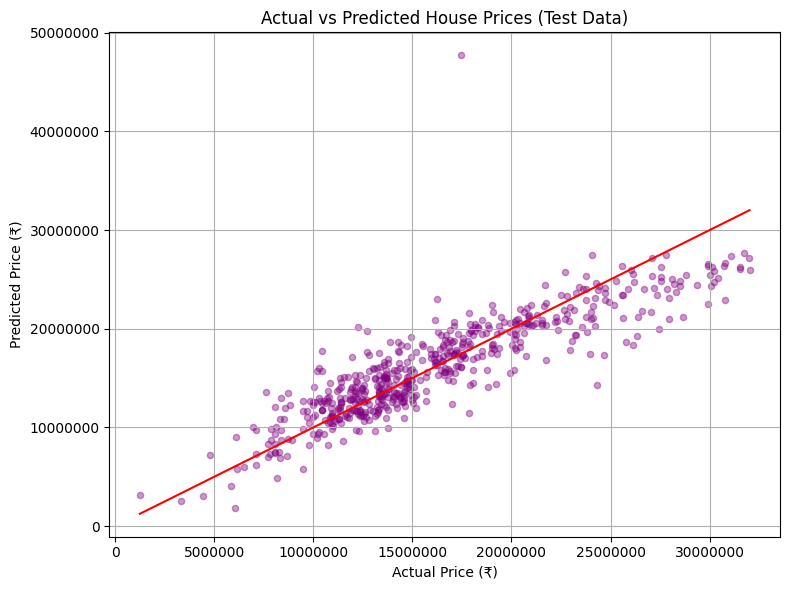

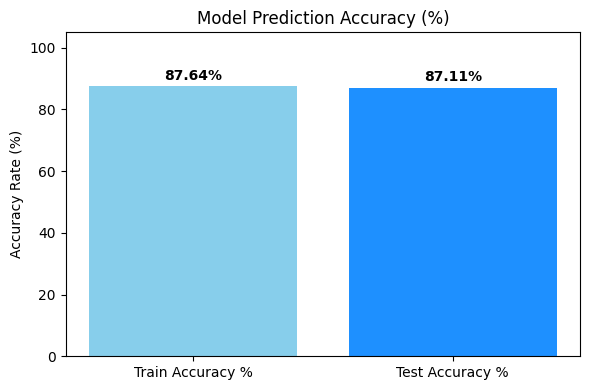

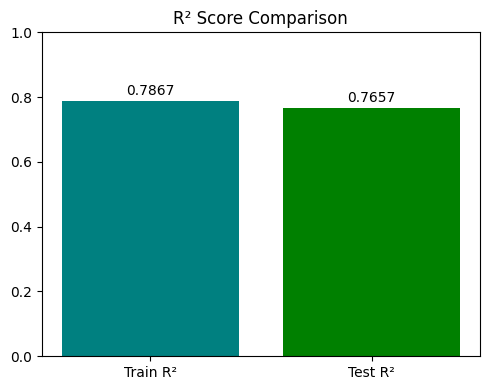


ENTER HOUSE DETAILS FOR PREDICTION
----------------------------------------
Overall Quality (1-10) [Default: 6]: 5
Ground Living Area (sq ft) [Default: 1417.0]: 1500
Garage Cars Capacity [Default: 2]: 3
Garage Area (sq ft) [Default: 470.0]: 500
Total Basement Area (sq ft) [Default: 971.5]: 1000
Year Built [Default: 1971]: 2022
Number of Full Bathrooms [Default: 2]: 3
Total Rooms Above Ground [Default: 6]: 5

PREDICTED HOUSE PRICE
----------------------------------------
₹1.75 Crore
----------------------------------------


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# =====================================================================
# 1. DATA LOADING & CLEANING
# =====================================================================
# Load dataset
df = pd.read_csv("/content/AmesHousing.csv")

# Remove extreme prices (Outliers) using IQR method
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["SalePrice"] >= lower) & (df["SalePrice"] <= upper)]

# Select features for the model
features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "Year Built",
    "Full Bath",
    "TotRms AbvGrd"
]

X = df[features]

# Fill missing values with median values
training_medians = X.median()
X = X.fillna(training_medians)

# Convert price from USD to INR
usd_to_inr = 95
y = df["SalePrice"] * usd_to_inr

# =====================================================================
# 2. MODEL TRAINING & EVALUATION
# =====================================================================
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Calculate training performance
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
accuracy_train = (1 - mean_absolute_percentage_error(y_train, y_train_pred)) * 100

# Calculate testing performance
y_test_pred = model.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
accuracy_test = (1 - mean_absolute_percentage_error(y_test, y_test_pred)) * 100

# Save predictions for plots
y_pred = y_test_pred

# Print data split information
print("\nDATASET SPLIT DETAILS")
print("-"*40)
print("Total Houses in Cleaned Data :", X.shape[0])
print("Houses used for Training (80%):", X_train.shape[0])
print("Houses used for Testing (20%) :", X_test.shape[0])

# Function to format price into Lakhs and Crores
def indian_currency(x):
    if x >= 10000000:
        return f"₹{x/10000000:.2f} Crore"
    elif x >= 100000:
        return f"₹{x/100000:.2f} Lakh"
    else:
        return f"₹{x:,.0f}"

# Print model scores
print("\nMODEL PERFORMANCE COMPARISON")
print("-" * 50)
print(f"{'Metric':<15} | {'Training Set':<16} | {'Testing Set':<16}")
print("-" * 50)
print(f"{'R² Score':<15} | {r2_train:<16.4f} | {r2_test:<16.4f}")
print(f"{'Accuracy (%)':<15} | {accuracy_train:<15.2f}% | {accuracy_test:<15.2f}%")
print("-" * 50)

# =====================================================================
# 3. VISUALIZATIONS
# =====================================================================
# Plot 1: Scatter plot of Actual vs Predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=20, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', label='Perfect Fit Line')
plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted House Prices (Test Data)")
plt.ticklabel_format(style='plain')
plt.grid(True)
plt.tight_layout()
plt.show(block=False)

# Plot 2: Bar chart for Accuracy Percentage
plt.figure(figsize=(6, 4))
plt.bar(["Train Accuracy %", "Test Accuracy %"], [accuracy_train, accuracy_test], color=['skyblue', 'dodgerblue'])
plt.ylabel("Accuracy Rate (%)")
plt.title("Model Prediction Accuracy (%)")
plt.ylim(0, 105)
for i, v in enumerate([accuracy_train, accuracy_test]):
    plt.text(i, v + 2, f"{v:.2f}%", ha="center", fontweight='bold')
plt.tight_layout()
plt.show(block=False)

# Plot 3: Bar chart for R2 Scores
plt.figure(figsize=(5, 4))
plt.bar(["Train R²", "Test R²"], [r2_train, r2_test], color=['teal', 'green'])
plt.ylim(0, 1)
plt.text(0, r2_train + 0.02, f"{r2_train:.4f}", ha="center")
plt.text(1, r2_test + 0.02, f"{r2_test:.4f}", ha="center")
plt.title("R² Score Comparison")
plt.tight_layout()
plt.show(block=False)

# =====================================================================
# 4. INTERACTIVE PREDICTION LOOP
# =====================================================================
print("\nENTER HOUSE DETAILS FOR PREDICTION")
print("-" * 40)

# Function to handle user inputs safely
def safe_input(prompt, default_val, cast_type):
    val = input(f"{prompt} [Default: {default_val}]: ").strip()
    if not val:
        return default_val
    try:
        return cast_type(val)
    except ValueError:
        print(f"  ⚠️ Invalid entry. Defaulting to fallback value: {default_val}")
        return default_val

# Get house details from user
overall_qual   = safe_input("Overall Quality (1-10)", int(training_medians["Overall Qual"]), int)
gr_living_area = safe_input("Ground Living Area (sq ft)", training_medians["Gr Liv Area"], float)
garage_cars    = safe_input("Garage Cars Capacity", int(training_medians["Garage Cars"]), int)
garage_area    = safe_input("Garage Area (sq ft)", training_medians["Garage Area"], float)
total_bsmt_sf  = safe_input("Total Basement Area (sq ft)", training_medians["Total Bsmt SF"], float)
year_built     = safe_input("Year Built", int(training_medians["Year Built"]), int)
full_bath      = safe_input("Number of Full Bathrooms", int(training_medians["Full Bath"]), int)
tot_rms        = safe_input("Total Rooms Above Ground", int(training_medians["TotRms AbvGrd"]), int)

# Format user input into a DataFrame
user_data = pd.DataFrame({
    "Overall Qual": [overall_qual],
    "Gr Liv Area": [gr_living_area],
    "Garage Cars": [garage_cars],
    "Garage Area": [garage_area],
    "Total Bsmt SF": [total_bsmt_sf],
    "Year Built": [year_built],
    "Full Bath": [full_bath],
    "TotRms AbvGrd": [tot_rms]
})

# Predict price for user input
predicted_price = model.predict(user_data)[0]

# Print final result
print("\nPREDICTED HOUSE PRICE")
print("-" * 40)
print(indian_currency(max(0, predicted_price)))
print("-" * 40)

# Keep plots open
plt.show()